In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
%matplotlib inline
sns.set_style('whitegrid')

In [7]:
df = pd.read_csv('../dataset/customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

1. Project Objective

The goal of this project is to build a predictive model to identify customers at high risk of churning (leaving the company). By predicting churn, the business can take proactive measures, such as offering discounts or loyalty programs, to retain valuable customers.

2. What we have seen so far (Initial Findings)

 . Dataset Structure: The data contains 7,043 entries and 21 features, covering demographics, services, and billing information.

 . Data Integrity: Most columns were correctly identified, but TotalCharges was improperly loaded as a string (object).

 . Data Cleaning: We identified that empty strings in TotalCharges represent customers with zero tenure, which we are handling by converting to numeric and removing nulls.

 . Target Imbalance: There is a clear imbalance between customers who stayed (No) and those who left (Yes), which will require specific evaluation metrics like Recall.

3. Project Roadmap (Next Steps)

 1 - Exploratory Data Analysis (EDA): Visualize correlations between features (like contract type and monthly charges) and churn.

 2 - Feature Engineering: Convert categorical text data into numerical format (Encoding).

 3 - Model Training: Compare different classification algorithms (e.g., Logistic Regression, Random Forest).

 4 - Evaluation: Use Confusion Matrix and Classification Report to measure performance beyond simple accuracy.

In [12]:
# Converting TotalCharges to numeric format to allow mathematical operations.
# Using 'errors=coerce' to transform blank spaces into NaN values for easier handling.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Identifying the number of missing values generated after conversion.
print(f"Null values found in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Dropping rows with missing values to ensure data quality.
# Given the small number of affected rows, this action does not bias the dataset.
df.dropna(inplace=True)

# Confirming successful conversion to float64.
print(df.info())

Null values found in TotalCharges: 0
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  703

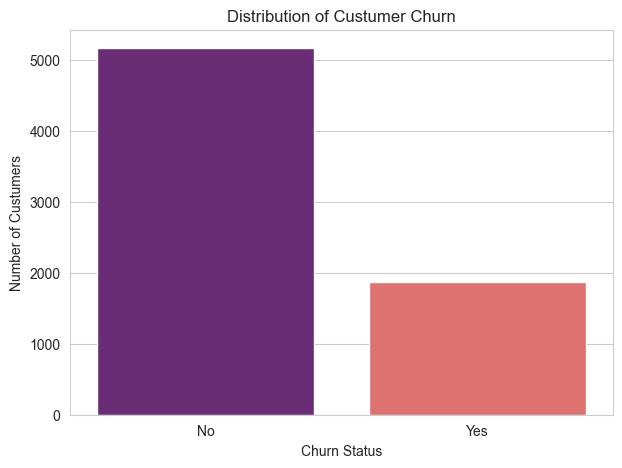


Churn Percentage Analysis:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [14]:
# Visualizing the distribution of the target variable to check for class imbalance.
plt.figure(figsize=(7,5))

# Updated version to comply with future Seaborn requirements
# Assigning 'x' to 'hue' to maintain color consistency and avoiding warnings
sns.countplot(x='Churn', data=df, hue='Churn', palette='magma', legend=False)

# Customizing plot aesthetics for better readability in the techinical report.
plt.title('Distribution of Custumer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Number of Custumers')
plt.show()

# Calculating the exact churn rate to establish a baseline for model evaluation.
print('\nChurn Percentage Analysis:')
print(df['Churn'].value_counts(normalize=True) * 100)

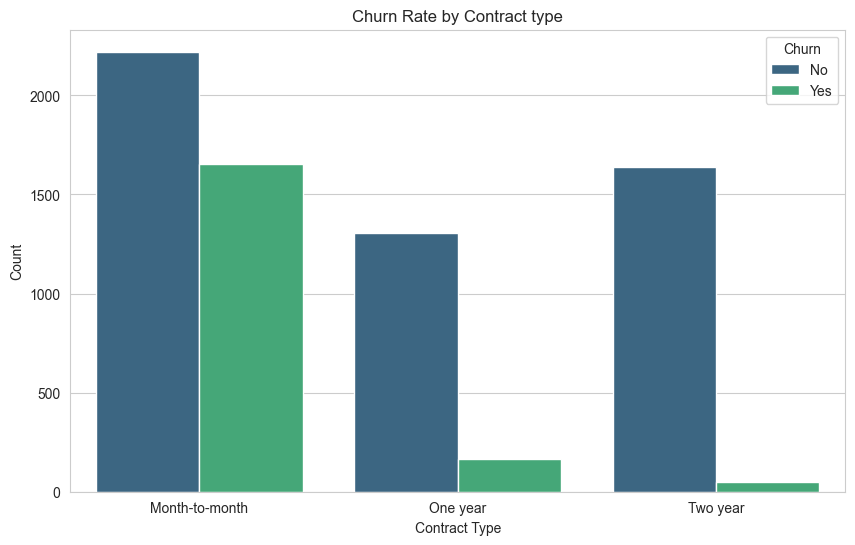

In [15]:
# Analyzing the relationship between Contract Type and Churn.
# this helps indentify if short-term contracts lead to higher attrition rates.
plt.figure(figsize=(10,6))
sns.countplot(x='Contract', data=df, hue='Churn', palette='viridis')

plt.title('Churn Rate by Contract type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

### **Key Insight: Contract Type vs. Churn**
* **Month-to-month contracts** represent the highest risk for the business, showing a significant churn volume.
* **Long-term contracts (1 and 2 years)** effectively act as a retention tool, with churn rates dropping near zero.
* **Business Recommendation:** Marketing strategies should focus on migrating "Month-to-month" customers to at least a 1-year plan to stabilize revenue.

Initial EDA suggests that month-to-month contracts have a significantly higher churn rate compared to long-term contracts.

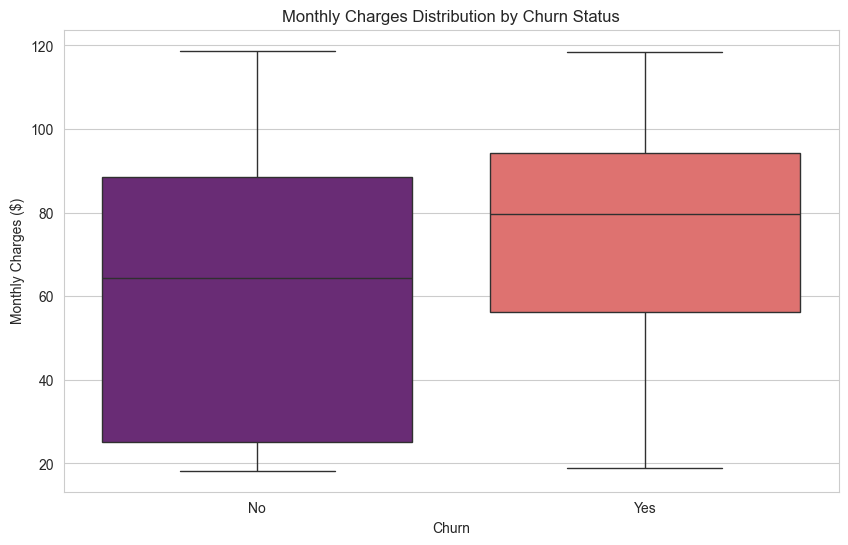

In [16]:
# Analyzing the impact of Monthly Charges on Churn
# Using a Bocplot to compare the distribution of costs for both groups.
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='magma')

plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

### **Key Insight: Monthly Charges vs. Churn**
* Customers who churn (**Yes**) have a significantly higher median monthly charge (~$80) compared to those who stay (~$65).
* This indicates that higher billing is a strong predictor of churn, possibly due to price sensitivity or customers perceiving lower value for higher-priced plans.
* **Business Impact:** The company is losing its most profitable customers. High-value loyalty programs or personalized discounts could be effective retention strategies here.

In [17]:
# Converting the target variable 'Churn' int numerical format
# Yes =1 , No = 0
df['Churn'] =df['Churn'].map({'Yes':1, 'No':0})

# Checking the transformation
print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [ ]:
# Executing One-Hot Encoding on categorical features.
# The 'drop_first=True' parameter is used to prevent the dummy variable trap,
# ensuring the model maintains mathematical stability by avoiding multicollinearity.

df_final = pd.get_dummies(df, drop_first=True)

# Visualizing the new structure of the dataset
print(f'Original columns: {df.shape[1]}')
print(f'Columns after enconding: {df_final.shape[1]}')
df_final.head()


Original columns: 21
Columns after enconding: 7062


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
# Dropping 'customerID' before encoding because it's a unique identifier 
# that doesn't provide predictive value and creates too many columns.
df.drop('customerID', axis=1, inplace=True)

# Now running get_dummies again on the remaining columns
df_final = pd.get_dummies(df, drop_first=True)

# Checking the new shape (it should be around 30-35 columns now)
print(f"Corrected columns after encoding: {df_final.shape[1]}")

Corrected columns after encoding: 31
